# 목차
1. [Variables](#variables)
2. [Packages](#packages)
3. [Check Data](#check-data)
4. [Preprocessing](#preprocessing)
5. [Modeling](#Modeling)
6. [Submission](#submission)

# packages

In [1]:
!pip install xgboost lightgbm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')


### 분석에 필요한 라이브러리를 한꺼번에 불러오는 셀
### pandas, numpy는 데이터 처리, matplotlib/seaborn은 시각화, sklearn은 전처리·모델·평가에 사용
### xgboost, lightgbm은 기본 설치가 안 돼있을 수 있어서 pip install로 먼저 설치

# check data

In [2]:
train_data_path = 'train.csv'
sub_data_path = 'test.csv'
sub_file_path = 'sample_submission.csv'


### 데이터 파일 경로를 변수로 관리함
### 나중에 경로가 바뀌어도 여기 한 곳만 수정하면 됨

In [3]:
data = pd.read_csv(train_data_path, index_col='id')
data['date'] = data['date'].apply(lambda i: i[:6]).astype(int)
display(data.head())
print(data.info())


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,,,
0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,201502,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


<class 'pandas.core.frame.DataFrame'>
Index: 15035 entries, 0 to 15034
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   price          15035 non-null  float64
 2   bedrooms       15035 non-null  int64  
 3   bathrooms      15035 non-null  float64
 4   sqft_living    15035 non-null  int64  
 5   sqft_lot       15035 non-null  int64  
 6   floors         15035 non-null  float64
 7   waterfront     15035 non-null  int64  
 8   view           15035 non-null  int64  
 9   condition      15035 non-null  int64  
 10  grade          15035 non-null  int64  
 11  sqft_above     15035 non-null  int64  
 12  sqft_basement  15035 non-null  int64  
 13  yr_built       15035 non-null  int64  
 14  yr_renovated   15035 non-null  int64  
 15  zipcode        15035 non-null  int64  
 16  lat            15035 non-null  float64
 17  long           15035 non-null  float64
 18  sqft_living

### train.csv를 불러와서 id를 인덱스로 설정
### date 컬럼은 '20141013T000000' 형태라 앞 6자리(연월)만 잘라서 정수로 변환
### head()로 데이터 형태 확인, info()로 타입과 결측치 여부 파악

In [4]:
print(data['date'].min(), data['date'].max())

201405 201505


### date의 최솟값과 최댓값을 출력해서 데이터가 어느 기간에 걸쳐 있는지 확인
### 201405 ~ 201505로 약 1년치 거래 데이터임을 알 수 있음

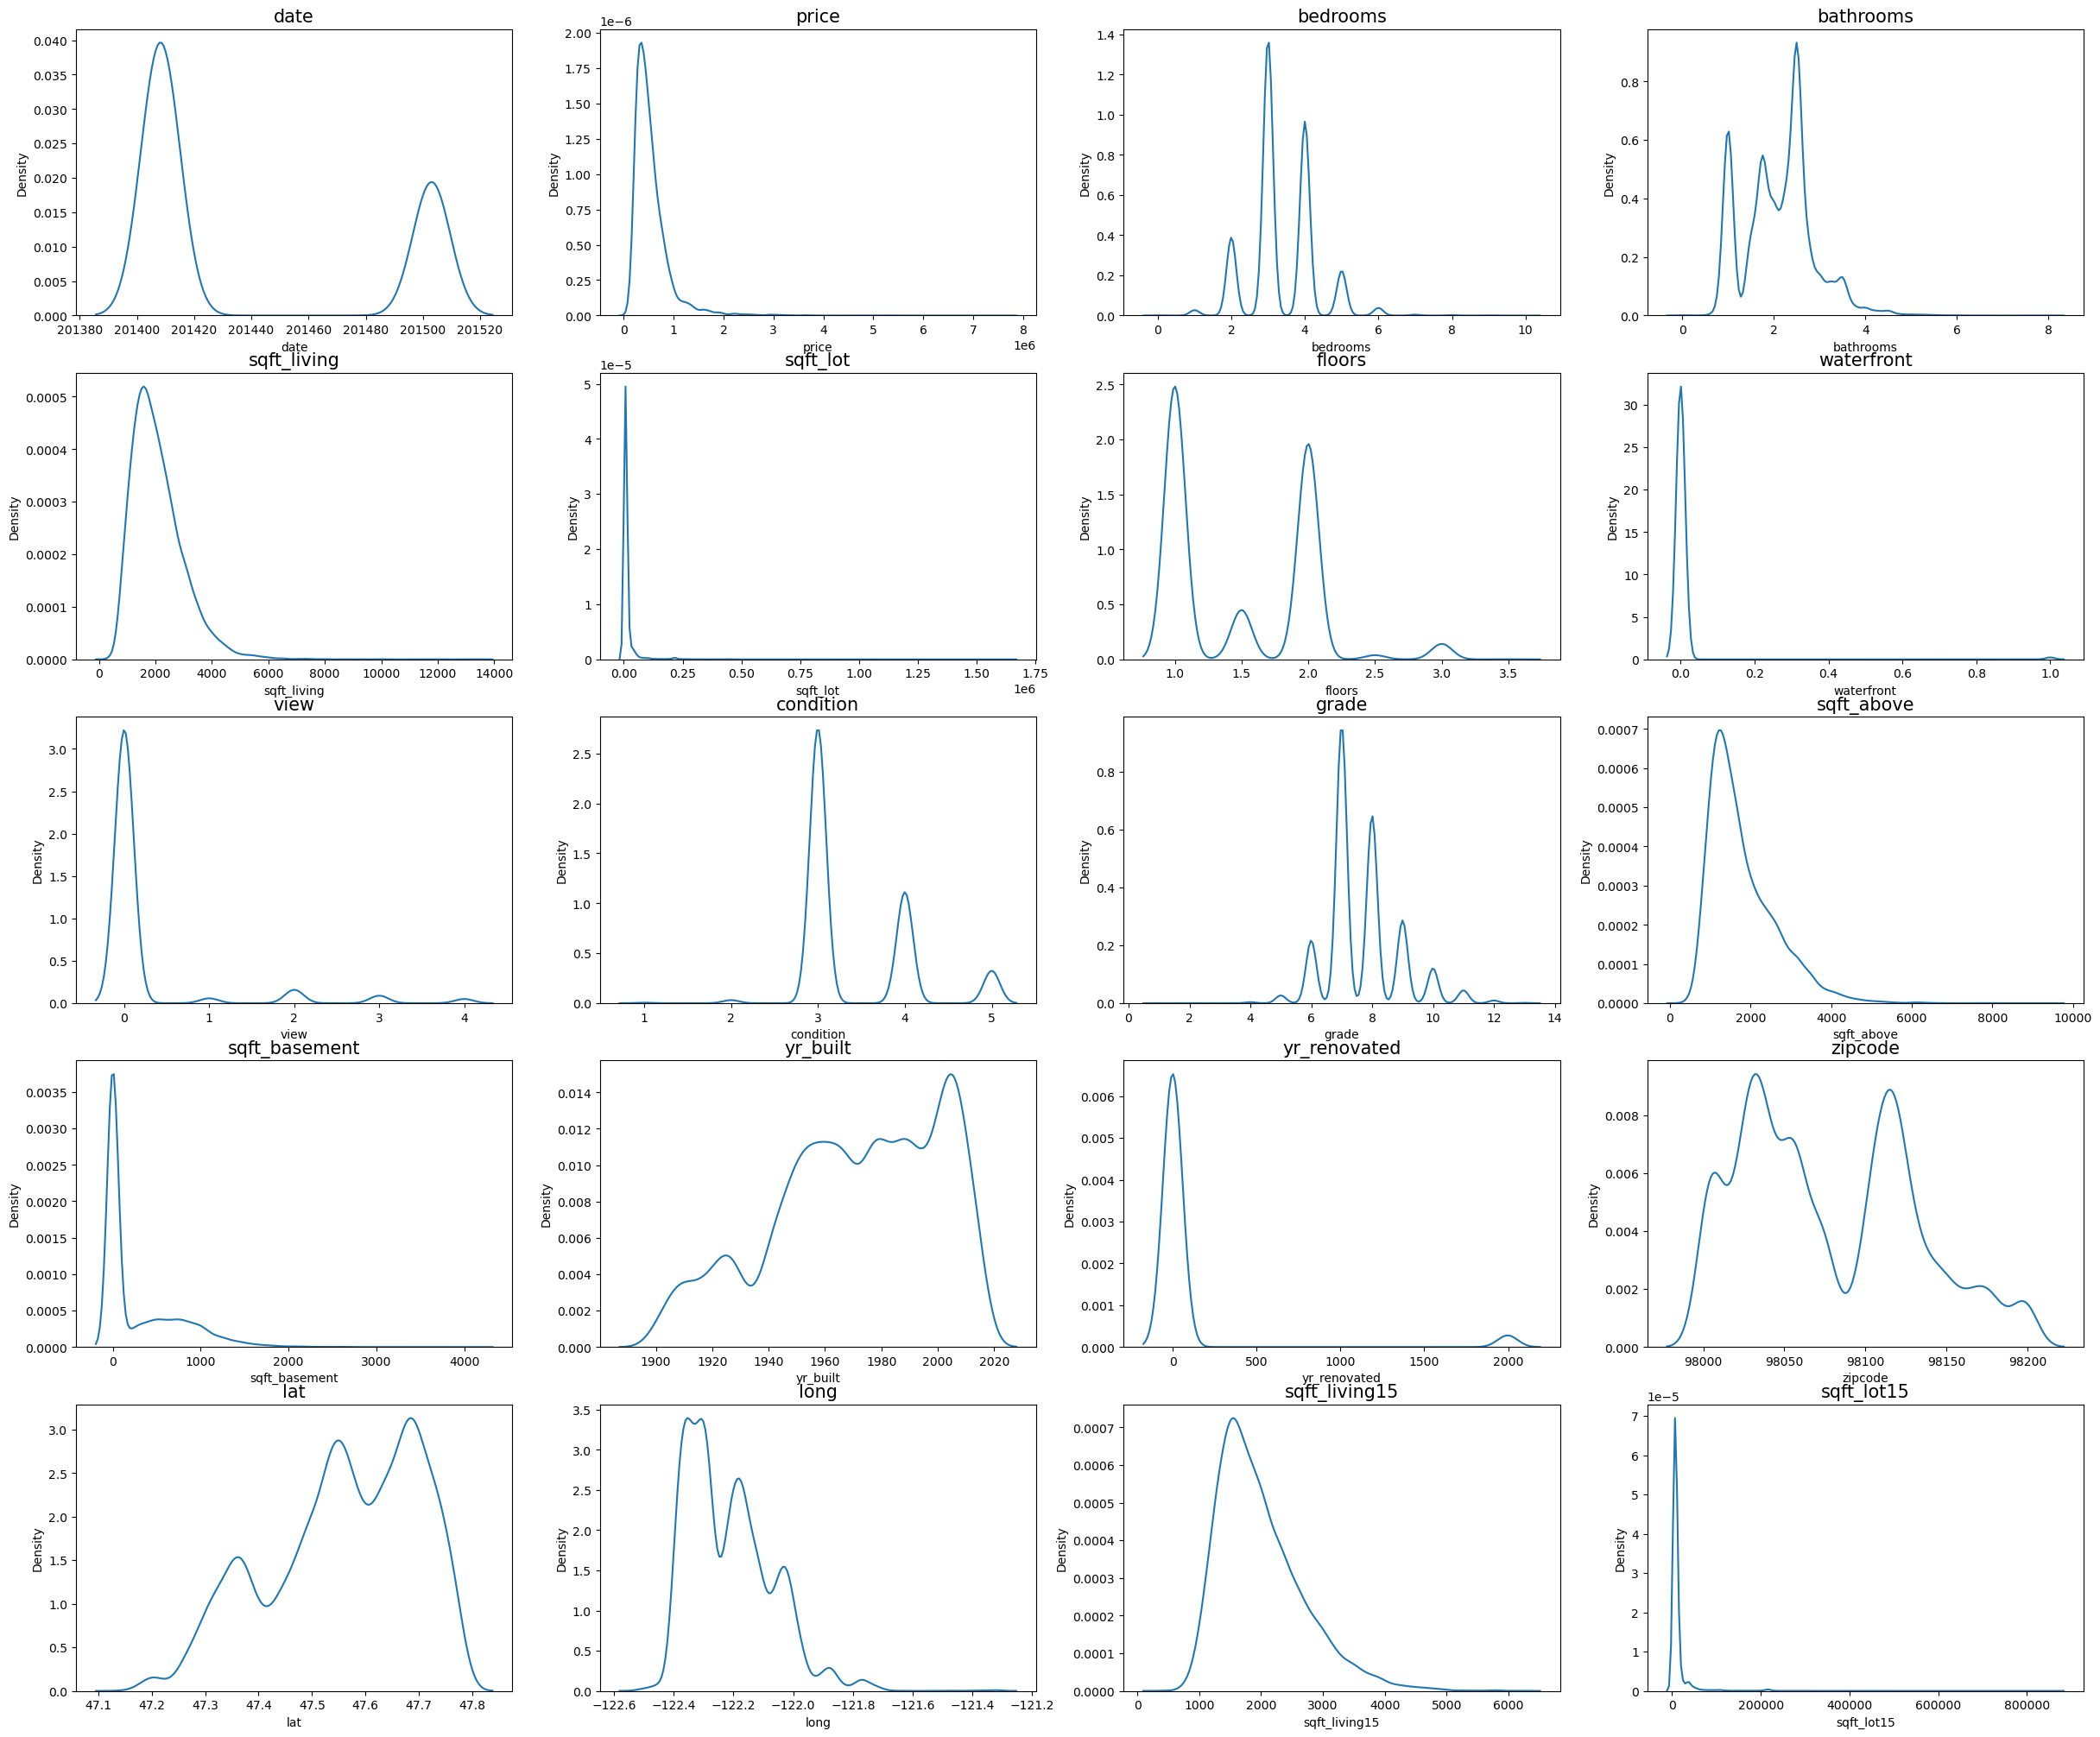

In [5]:
fig, ax = plt.subplots(5, 4, figsize = (30, 25))

columns = data.columns
count = 0
for row in range(5):
    for col in range(4):
        sns.kdeplot(data[columns[count]], ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count += 1
plt.show()

### 모든 컬럼의 분포를 KDE(커널 밀도 추정) 그래프로 한눈에 확인
### 정규분포에 가까운지, 한쪽으로 치우쳐 있는지(스큐) 파악하는 단계
### price, sqft 계열 변수들이 오른쪽으로 치우친 분포를 보임 → 로그 변환 필요성 확인

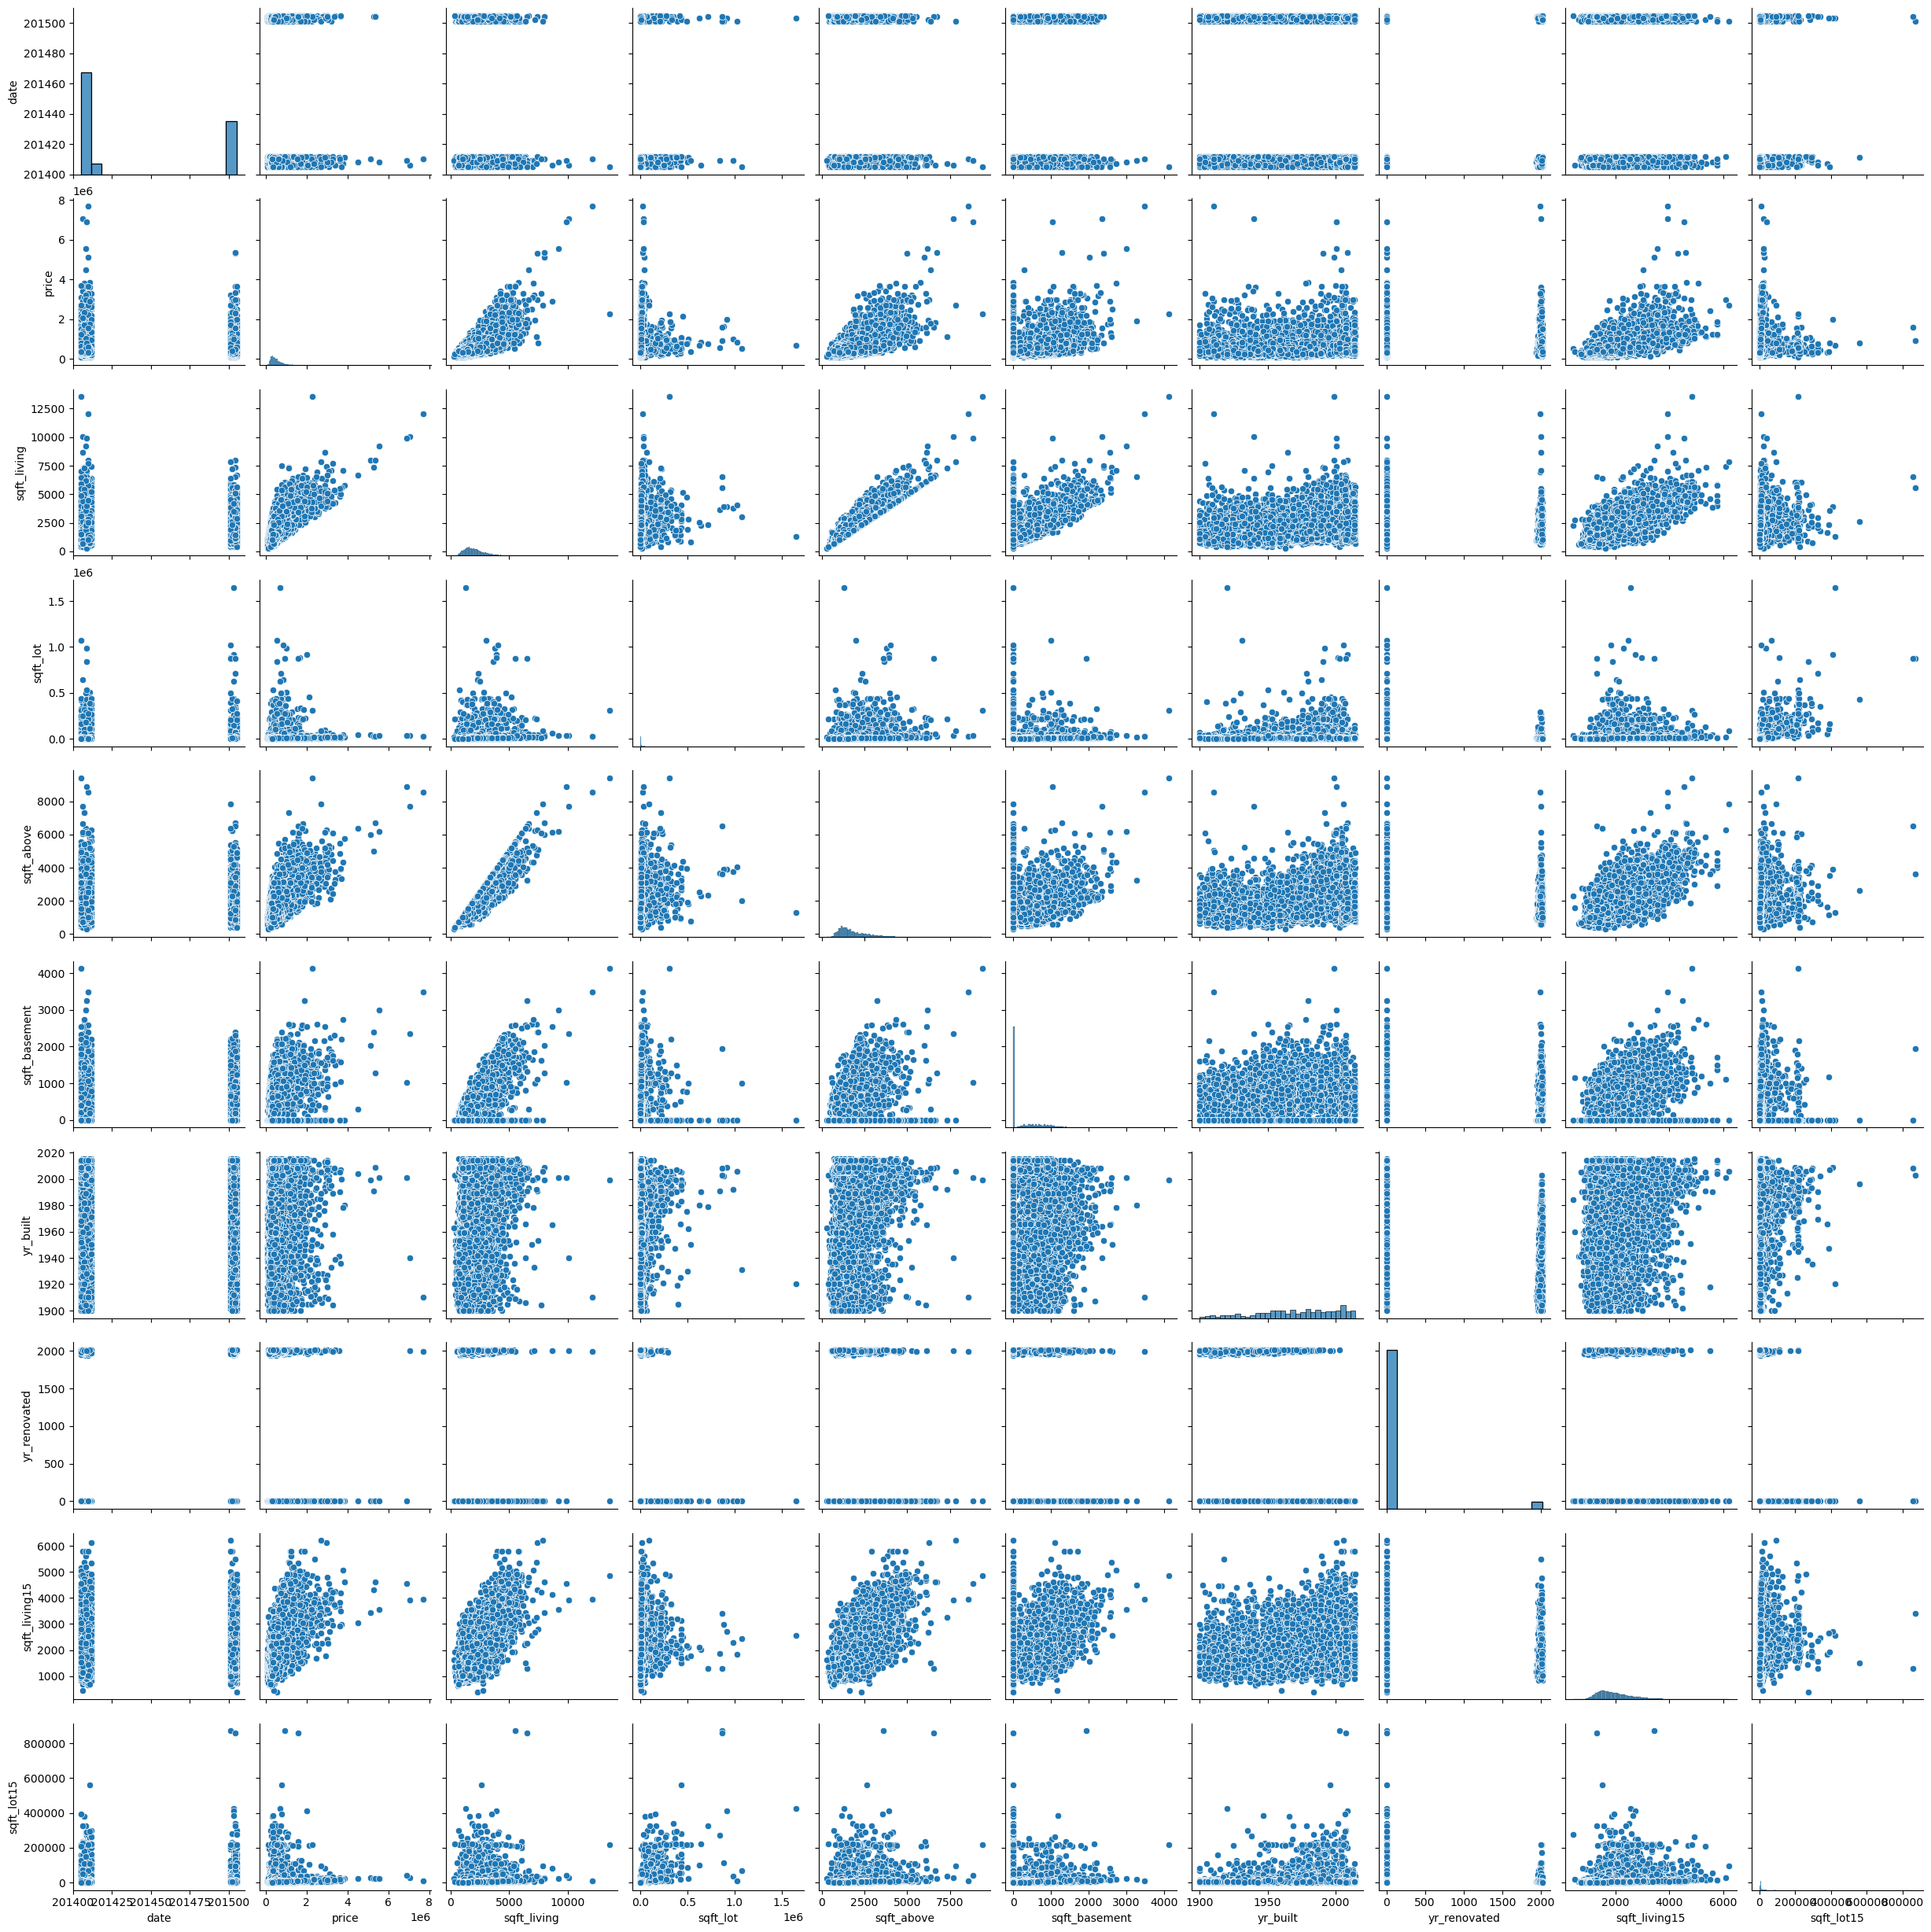

In [6]:
scatter_cols = [
    'date', 'price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement',
    'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15'
]
sns.pairplot(data[scatter_cols])
plt.show()

### 주요 수치형 변수들 간의 산점도와 분포를 pairplot으로 한꺼번에 시각화
### price와 sqft_living 간에 양의 선형 관계가 보이고, 면적 관련 변수들끼리도 서로 상관관계가 높음

In [7]:
print(data['yr_renovated'].describe())

count    15035.000000
mean        83.798936
std        400.398498
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2015.000000
Name: yr_renovated, dtype: float64


### yr_renovated(재건축 연도) 통계를 확인
### 평균이 83 수준이고 중앙값이 0인 걸 보면 대부분의 집이 재건축을 안 한 것
### 연속형으로 쓰기엔 0이 너무 많아서 재건축 여부 이진변수로 쓰는 게 더 효과적임

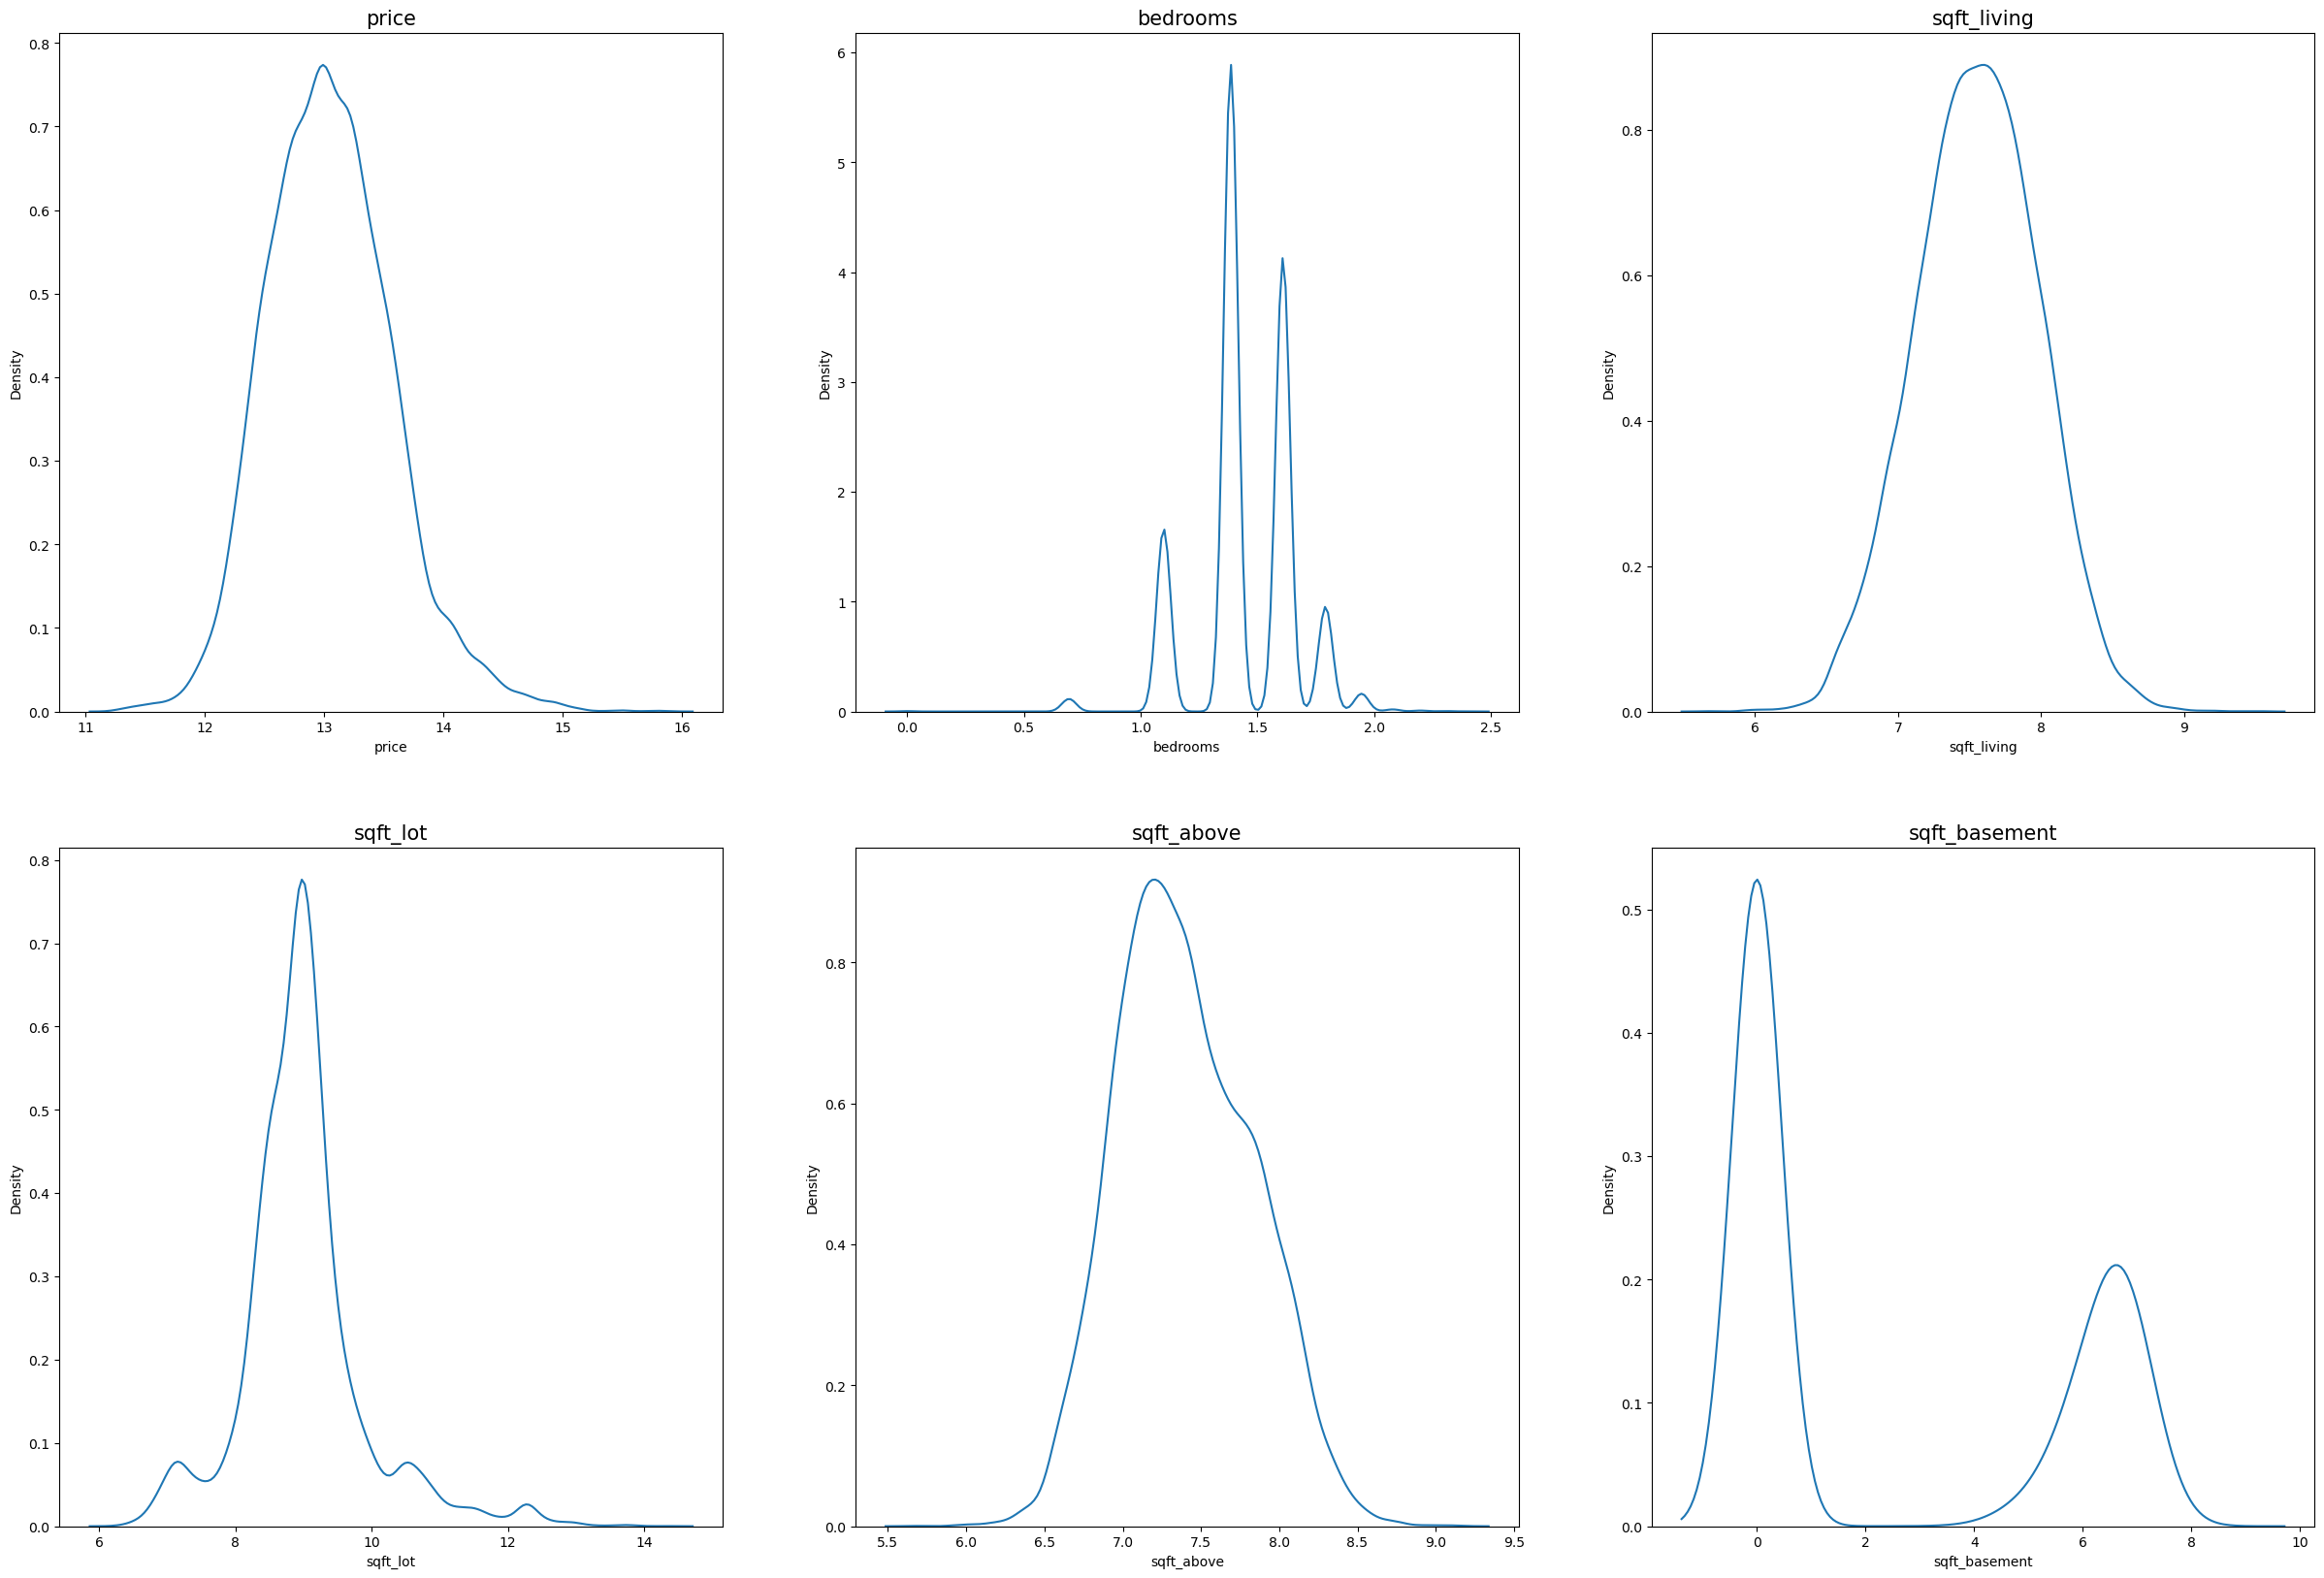

In [8]:
skew_columns = ['price', 'bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

for c in skew_columns:
    data[c] = np.log1p(data[c].values)

fig, ax = plt.subplots(2, 3, figsize = (30, 20))

count = 0
for row in range(2):
    for col in range(3):
        sns.kdeplot(data[skew_columns[count]], ax=ax[row][col])
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        count += 1
plt.show()

### 우편향이 심한 6개 변수에 np.log1p()를 적용해서 분포를 정규분포에 가깝게 변환
### log1p는 log(1+x)라서 값이 0일 때도 안전하게 처리됨
### 변환 후 KDE 그래프에서 좌우 대칭에 가까워진 걸 확인할 수 있음
### 이 변환 덕분에 이상치(고가 주택)가 RMSE를 크게 끌어올리는 현상이 완화됨

In [9]:
print(data.describe())

                date         price      bedrooms     bathrooms   sqft_living  \
count   15035.000000  15035.000000  15035.000000  15035.000000  15035.000000   
mean   201438.545993     13.048122      1.452912      2.115065      7.552362   
std        44.252050      0.527471      0.210784      0.767519      0.425656   
min    201405.000000     11.264477      0.000000      0.000000      5.673323   
25%    201407.000000     12.682310      1.386294      1.750000      7.266129   
50%    201410.000000     13.017005      1.386294      2.250000      7.555382   
75%    201502.000000     13.377007      1.609438      2.500000      7.848153   
max    201505.000000     15.856731      2.397895      8.000000      9.513477   

           sqft_lot        floors    waterfront          view     condition  \
count  15035.000000  15035.000000  15035.000000  15035.000000  15035.000000   
mean       8.992803      1.498071      0.007117      0.234253      3.406651   
std        0.905809      0.538522      0.0

### 로그 변환 후 각 변수의 기술통계를 확인
### 변환 전에 비해 최댓값과 평균의 차이가 크게 줄어든 걸 확인할 수 있음

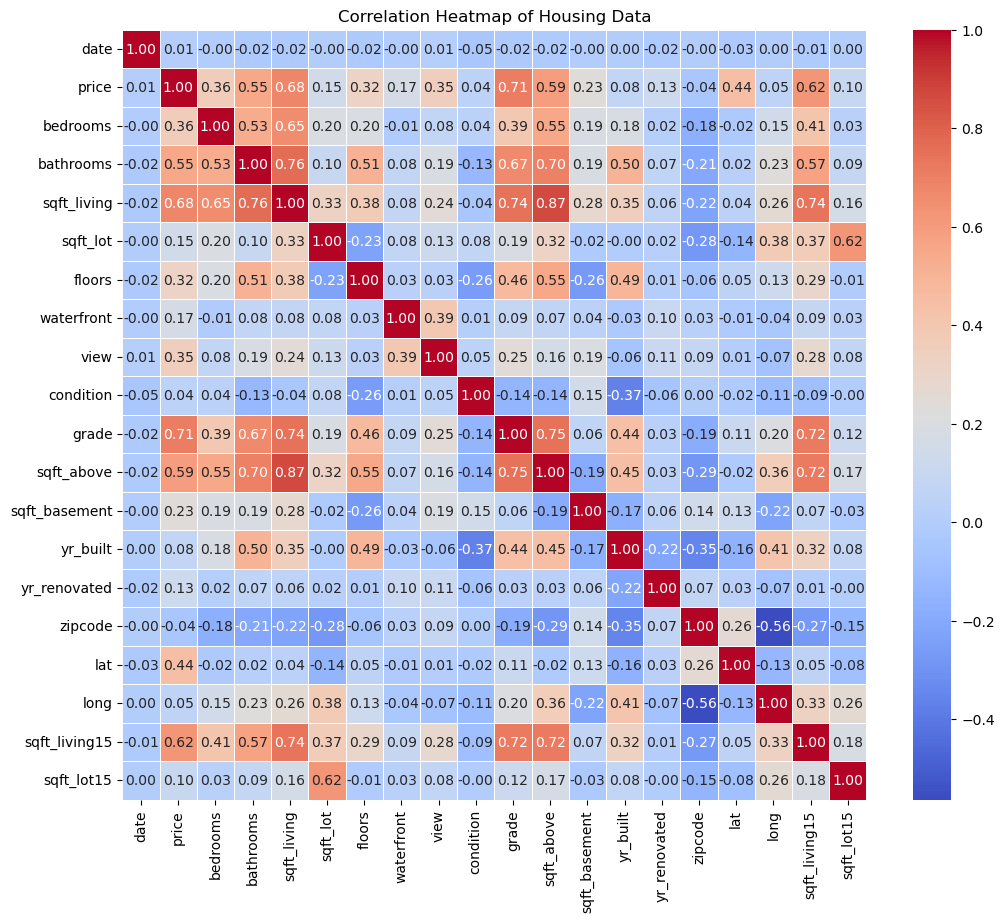

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Housing Data")
plt.show()

### 변수 간 상관계수를 히트맵으로 시각화
### price와 상관관계가 높은 변수: sqft_living, grade, sqft_above, bathrooms, lat 순
### sqft_living과 sqft_above 간 상관관계가 매우 높음 → 다중공선성 주의

In [11]:
X = data.drop('price', axis = 1)
y = data['price']

random_state = 526

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    random_state = random_state)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(12028, 19) (3007, 19)
(12028,) (3007,)


### price를 타겟(y)으로 분리하고 나머지를 피처(X)로 설정
### 전체 데이터의 80%를 학습, 20%를 검증에 사용
### random_state=526으로 고정해서 실행할 때마다 동일한 분할이 되도록 함

# preprocessing
## scaling

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### StandardScaler로 각 피처를 평균 0, 표준편차 1로 정규화
### fit_transform은 train에만 적용하고, test는 transform만 적용해야 데이터 누수가 없음
### 트리 기반 모델은 스케일링이 필수는 아니지만 SelectKBest, PCA 전처리를 위해 적용

## 변수선택

In [13]:
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

### f_regression 기준으로 price와 상관관계가 높은 상위 10개 변수만 선택
### 불필요한 변수를 제거해서 모델의 과적합을 방지하고 학습 속도를 높임

## pca

In [14]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

### PCA로 선택된 10개 변수의 차원을 축소
### n_components=0.95는 전체 분산의 95%를 설명하는 최소한의 주성분 수를 자동으로 결정
### 딥러닝 모델에 입력할 때 쓰이는 전처리 결과임 (LightGBM에는 적용 안 함)

# Modeling
## stack_reg again

## lightgbm
### RandomizedSearchCV

In [15]:
param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 30),
    'subsample': uniform(0.6, 0.4),  # 0.6부터 1.0까지의 값 중에서 랜덤 샘플링
    'colsample_bytree': uniform(0.6, 0.4),  # 0.6부터 1.0까지의 값 중에서 랜덤 샘플링
    'reg_alpha': uniform(0, 0.2),
    'reg_lambda': uniform(0, 0.2)
}

lightgbm = LGBMRegressor(random_state=random_state)
model = RandomizedSearchCV(estimator = lightgbm,
                          param_distributions = param_dist,
                          cv = 5,
                          scoring = 'neg_mean_squared_error',
                          n_jobs = -1,
                          random_state = random_state)
model.fit(X_train, y_train)
best_model = model.best_estimator_

y_pred = best_model.predict(X_test)

print(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2288
[LightGBM] [Info] Number of data points in the train set: 9622, number of used features: 19
[LightGBM] [Info] Start training from score 13.044961
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, 

### LightGBM에 RandomizedSearchCV를 적용해서 최적 하이퍼파라미터를 자동으로 탐색
### param_dist에 정의된 범위에서 무작위로 조합을 뽑아 5-fold 교차검증으로 평가
### scoring='neg_mean_squared_error'를 쓰는 이유는 sklearn이 점수가 클수록 좋다는 기준으로 작동해서 MSE에 음수를 붙인 것
### 탐색 완료 후 best_estimator_에 최적 파라미터로 학습된 모델이 저장됨
### 출력된 RMSE는 로그 변환된 예측값과 실제값을 expm1()으로 복원한 실제 가격 단위 오차

# submission

In [16]:
def preprocessing(data):
    data['date'] = data['date'].apply(lambda i: i[:6]).astype(int)
    skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']
    for c in skew_columns:
        data[c] = np.log1p(data[c].values)
    return data


### test 데이터에 train과 동일한 전처리를 적용하는 함수
### date 변환과 5개 변수 로그 변환만 적용 (price는 test에 없으니 제외)
### train 전처리와 완전히 동일하게 맞춰야 모델이 올바르게 예측할 수 있음

In [17]:
submission = pd.read_csv(sub_file_path)
submission.head()

,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


### 제출 양식 파일을 불러와서 id 컬럼 구조 확인
### 이 id 순서에 맞춰 price를 채워넣어야 함

In [18]:
test = pd.read_csv(sub_data_path, index_col = 'id')
test = preprocessing(test)

### test.csv를 불러와서 preprocessing 함수로 전처리
### train과 동일한 변환이 적용됨

In [19]:
pred = best_model.predict(test)
pred = np.expm1(pred)
print(pred, len(pred))

[1390758.45714464  328590.06881774  690346.96820611 ... 2019396.10948967
  410741.31027428  327557.2123566 ] 6555


### 학습된 best_model로 test 예측 후 expm1()으로 복원
### 모델이 log(price)를 예측했으니 실제 가격으로 되돌리는 과정

In [20]:
submission['price'] = pred[:len(submission)]
submission.head()


,id,price
0,15035,1.390758e+06
1,15036,3.285901e+05
2,15037,6.903470e+05
3,15038,1.963166e+05
4,15039,4.209662e+05


### 예측값을 submission의 price 컬럼에 채워넣음
### pred[:len(submission)]으로 슬라이싱해서 행 수가 다를 경우 발생하는 오류를 방지

In [21]:
submission.to_csv('submission.csv', index=False)
print('저장 완료: submission.csv')
print(submission['price'].describe())


저장 완료: submission.csv
count    6.468000e+03
mean     5.288712e+05
std      3.353258e+05
min      1.067771e+05
25%      3.168595e+05
50%      4.492190e+05
75%      6.313325e+05
max      4.273951e+06
Name: price, dtype: float64


### 최종 예측값을 submission.csv로 로컬에 저장
### index=False로 인덱스 번호가 파일에 포함되지 않게 함
### price 기술통계로 예측값 분포가 이상하지 않은지 최종 확인

---

## 결과 요약

LightGBM에 RandomizedSearchCV를 적용한 모델이 가장 좋은 성능을 냈음.  
트리 기반 모델 특성상 스케일링이나 PCA보다 **로그 변환만 적용한 원본 피처**를 그대로 쓰는 게 더 효과적이었음.  
RandomizedSearchCV는 모든 조합을 다 탐색하는 GridSearch와 달리 무작위 샘플링 + 교차검증 방식이라 시간 대비 좋은 파라미터를 찾아낼 수 있음.